# Module 1: Deep Agents

> Part of the **Modular Workshops** series. Standalone, ~45 min.

Deep Agents = `create_agent()` + a pre-built middleware stack (filesystem, planning, subagents, context management). We'll build up from a bare agent to a fully-featured research assistant, exploring:

- The harness and built-in tools
- Custom tools (Tavily search)
- Subagents and context isolation
- Backends and persistent memory
- Middleware (compliance, audit)
- Human-in-the-loop on tool calls
- AGENTS.md and Skills


## Setup

In [1]:
import sys
from pathlib import Path
project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from utils.models import model

from langchain_core.tools import tool
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import Command
from langsmith import uuid7
from IPython.display import Image, display

# Start each run with a clean long-term memory store (section 1.4 recreates it).
for f in Path().glob("deep_agents_memory.db*"):
    f.unlink()

print("Ready")

Ready


---
# Part 1: Deep Agents

Deep Agents = `create_agent()` + a pre-built middleware stack (filesystem, planning, subagents, context management).

We'll build up from a bare agent to a fully-featured research assistant.

## 1.1 Your First Deep Agent

`create_deep_agent()` gives you a filesystem, a todo list, and context management out of the box — no tools required.

<img src="../images/deepAgentsDiag.png" style="width: auto; max-height: 420px; border-radius: 8px;">

### What you get for free:

- **Filesystem Tools** — `ls`, `read_file`, `write_file`, `edit_file`, `glob`, `grep`
- **Planning Tool** — `write_todos` for task tracking
- **Subagent Delegation** — `task()` tool for isolated work
- **Large Tool Result Eviction** — Automatically offloads tool results >20k tokens to the filesystem
- **Conversation Summarization** — Compresses history when approaching ~85% context capacity
- **Dangling Tool Call Patching** — Fixes message history consistency automatically


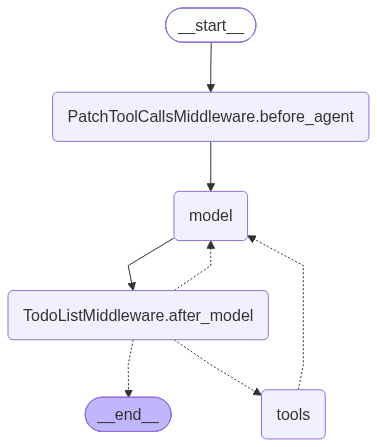

In [2]:
from deepagents import create_deep_agent

agent = create_deep_agent(
    model=model,
    system_prompt="You are a helpful assistant.",
    checkpointer=MemorySaver(),
)
agent

In [3]:
# The agent can already write and read files — these are built-in tools
config = {"configurable": {"thread_id": str(uuid7())}}
result = agent.invoke({
    "messages": [{"role": "user", "content": "Write a haiku about AI to /haiku.txt, then read it back to me."}]
}, config=config)

for m in result["messages"]:
    m.model_copy(update={"content": m.text}).pretty_print()

================================ Human Message =================================

Write a haiku about AI to /haiku.txt, then read it back to me.
================================== Ai Message ==================================
Tool Calls:
  write_file (toolu_01SdVi3ua3v7maL5vHSnqBiQ)
 Call ID: toolu_01SdVi3ua3v7maL5vHSnqBiQ
  Args:
    file_path: /haiku.txt
    content: Silent circuits hum,
thoughts born of light and numbers—
a new mind awakes.
================================= Tool Message =================================
Name: write_file

Updated file /haiku.txt
================================== Ai Message ==================================
Tool Calls:
  read_file (toolu_019MHLcfiCUfWc7GsSHK3ZNh)
 Call ID: toolu_019MHLcfiCUfWc7GsSHK3ZNh
  Args:
    file_path: /haiku.txt
================================= Tool Message =================================
Name: read_file

     1	Silent circuits hum,
     2	thoughts born of light and numbers—
     3	a new mind awakes.
=====================

In [4]:
# Helper: print the virtual filesystem from a deep agent result.
def print_files(result, header="VIRTUAL FILESYSTEM (in-memory, not on disk!)"):
    files = result.get("files") or {}
    if not files:
        print("(no files in state)")
        return
    print("=" * 50)
    print(header)
    print("=" * 50)
    for path, file_data in files.items():
        print(f"\n  Path: {path!r}")
        print("  " + "-" * 38)
        content = file_data
        if isinstance(file_data, dict) and "content" in file_data:
            content = file_data["content"]
        if isinstance(content, list):
            content = "\n".join(content)
        for line in str(content).split("\n"):
            print(f"  | {line}")

print_files(result)


VIRTUAL FILESYSTEM (in-memory, not on disk!)

  Path: '/haiku.txt'
  --------------------------------------
  | Silent circuits hum,
  | thoughts born of light and numbers—
  | a new mind awakes.
  | 


### Filesystem persistence within a thread

By default, `create_deep_agent()` uses **StateBackend** — files are stored in agent state and persist within a thread (via the checkpointer), but disappear when you start a new thread.

| Backend | Storage | Persistence | Use Case |
|---------|---------|-------------|----------|
| **StateBackend** | In-memory (agent state) | Single thread | Scratch pads, intermediate results |
| **FilesystemBackend** | Local disk | Permanent | Direct file access (use with caution) |
| **StoreBackend** | LangGraph Store | Cross-thread | Long-term memories |
| **CompositeBackend** | Routes to others | Mixed | Selective persistence |

In [5]:
# Same thread — the file persists via the checkpointer
result = agent.invoke({
    "messages": [{"role": "user", "content": "Read the file /haiku.txt"}]
}, config=config)

print("Same thread:\n\n", result["messages"][-1].text)

Same thread:

 Silent circuits hum,
thoughts born of light and numbers—
a new mind awakes.


In [6]:
# New thread — StateBackend is ephemeral, so the file is gone
new_config = {"configurable": {"thread_id": str(uuid7())}}

result = agent.invoke({
    "messages": [{"role": "user", "content": "List all files with ls /"}]
}, config=new_config)

print("New thread:", result["messages"][-1].text)

New thread: The root directory `/` is empty — no files or directories found.


### Key Takeaway
- `create_deep_agent()` gives you filesystem + planning capabilities for free
- Files are stored in agent state (virtual, not on disk)
- `StateBackend` (default) persists within a thread but is ephemeral across threads
- We'll see how to make files persist across threads with `CompositeBackend` + `StoreBackend` in section 1.4

## 1.2 Custom Tools

Add your own tools alongside the built-in ones. We define `tavily_search` inline with `@tool` so the pattern stays visible; the body delegates to `resilient_tavily_search` from `utils/search.py`, which retries on Tavily failure and falls back to a canned response so the demo doesn't break on a flaky network.


In [7]:
from utils.search import resilient_tavily_search

@tool(parse_docstring=True)
def tavily_search(query: str) -> str:
    """Search the web for information on a given query.

    Args:
        query: Search query to execute.
    """
    # `resilient_tavily_search` retries on Tavily failure and falls back to a
    # topic-matched canned response. See utils/search.py.
    return resilient_tavily_search(query, max_retries=2)

agent = create_deep_agent(
    model=model,
    tools=[tavily_search],
    system_prompt="You are a helpful research assistant.",
    checkpointer=MemorySaver(),
)

config = {"configurable": {"thread_id": str(uuid7())}}
result = agent.invoke({
    "messages": [{"role": "user", "content": "What is Deep Agents? Write a one-paragraph summary to /summary.md"}]
}, config=config)

print("Agent reply:", result["messages"][-1].text)

Agent reply: Deep Agents (`deepagents`) is a LangChain library built on LangGraph that acts as an "agent harness" — it wraps the standard tool-calling agent loop with production-grade built-ins: a virtual file system for context management, subagent spawning for delegation, optional long-horizon task planning, and long-term memory/context offloading. It's the architecture behind agent products like Claude Code, Deep Research, and Manus, letting developers build reliable multi-step agents (via `create_deep_agent()`) without hand-building that infrastructure themselves.

I've saved the full one-paragraph summary to `/summary.md`.


In [8]:
# Print state of virtual file system
print_files(result)

VIRTUAL FILESYSTEM (in-memory, not on disk!)

  Path: '/summary.md'
  --------------------------------------
  | # What is Deep Agents?
  | 
  | Deep Agents (`deepagents`) is a standalone Python library, built by LangChain on top of LangGraph, that functions as an "agent harness" for building reliable, production-grade LLM-powered agents capable of handling complex, multi-step tasks. Rather than replacing LangChain or LangGraph, it sits atop LangGraph's durable execution runtime and adds an opinionated set of built-in capabilities that would otherwise need to be hand-built: a virtual file system and context-management tools (summarization, context offloading, prompt caching, and reusable "skills") for handling long-running context, the ability to spawn subagents to delegate isolated pieces of work, optional long-horizon task planning, and long-term memory. Using a simple entry point like `create_deep_agent()`, developers get the same core tool-calling loop found in other agent framewor

## 1.3 Subagents: Isolated Delegation

Subagents run in a separate context. The main agent delegates via `task()` and only sees the final result — keeping the main context clean.

<img src="../images/deepAgentSubagents.png" style="width: auto; max-height: 380px; border-radius: 8px;">


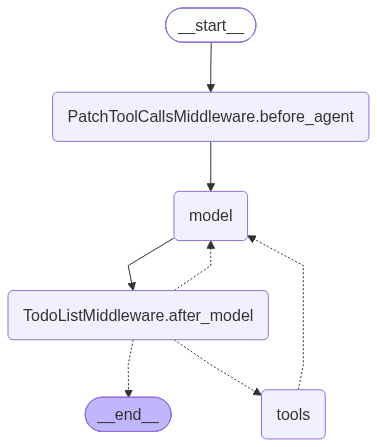

In [9]:
from datetime import datetime

research_subagent = {
    "name": "research-agent",
    "description": "Delegate research tasks. Give one topic at a time.",
    "system_prompt": f"""You are a research assistant. Today is {datetime.now().strftime('%Y-%m-%d')}.
Use tools to gather information. Structure findings with clear headings and inline citations.
Limit to 3 search calls.""",
    "tools": [tavily_search],
}

agent = create_deep_agent(
    model=model,
    system_prompt="""You are a research coordinator.
Delegate research to the research-agent using the task() tool.
Synthesize findings and write a report.""",
    subagents=[research_subagent],
    checkpointer=MemorySaver(),
)
agent

In [11]:
config = {"configurable": {"thread_id": str(uuid7())}}
result = agent.invoke({
    "messages": [{"role": "user", "content": "Lightly research the latest news on AI agents this week"}]
}, config=config)

def truncate(text, limit=1000):
    return text if len(text) <= limit else text[:limit] + "…"

for m in result["messages"]:
    m.model_copy(update={"content": truncate(m.text)}).pretty_print()

Error in LangChainTracer.on_chain_end callback: TracerException('No indexed run ID 019fc5b7-7632-7ea0-9f01-3634d2c94f85.')
Error in LangChainTracer.on_llm_end callback: TracerException('No indexed run ID 019fc5b7-763a-7321-afcd-1004489e5378.')
Error in LangChainTracer.on_chain_end callback: TracerException('No indexed run ID 019fc5b7-7635-76a0-bc20-17f2eb8afa96.')
Error in LangChainTracer.on_chain_end callback: TracerException('No indexed run ID 019fc5b7-8b46-7f63-84a9-7be5c23ba2ae.')
Error in LangChainTracer.on_tool_end callback: TracerException('No indexed run ID 019fc5b7-8b4a-73a0-977f-3da0f1da9572.')
Error in LangChainTracer.on_chain_end callback: TracerException('No indexed run ID 019fc5b7-8b48-7b50-9fe3-8dd2a12b1e1e.')
Error in LangChainTracer.on_llm_end callback: TracerException('No indexed run ID 019fc5b7-8b53-7f23-9308-72941e37551b.')
Error in LangChainTracer.on_chain_end callback: TracerException('No indexed run ID 019fc5b7-8b4d-7f02-9082-517deb8038e6.')
Error in LangChainTra

================================ Human Message =================================

Lightly research the latest news on AI agents this week
================================== Ai Message ==================================
Tool Calls:
  write_todos (toolu_01CL2sGxUFSG4KaWDorY5MN2)
 Call ID: toolu_01CL2sGxUFSG4KaWDorY5MN2
  Args:
    todos: [{'content': 'Delegate research on latest AI agents news this week to research-agent', 'status': 'in_progress'}, {'content': 'Synthesize findings into a concise report', 'status': 'pending'}]
================================= Tool Message =================================
Name: write_todos

Updated todo list to [{'content': 'Delegate research on latest AI agents news this week to research-agent', 'status': 'in_progress'}, {'content': 'Synthesize findings into a concise report', 'status': 'pending'}]
================================== Ai Message ==================================
Tool Calls:
  task (toolu_01KzFWCypnaVSPLcGnrDm5Eo)
 Call ID: toolu_01KzFWCy

## 1.4 Backends & Memory

By default, files live in ephemeral state (`StateBackend`). Use `CompositeBackend` to route paths — e.g. `/memories/` to persistent `StoreBackend` while everything else stays ephemeral.

`StoreBackend` is a database-backed store meant to persist memory across threads. Here we back it with a local SQLite file, but the LangGraph `Store` can be backed by the database of your choice (Postgres, etc.).

`StoreBackend` scopes what it reads and writes by `namespace` — a required argument, and your lever for isolation: per user, per assistant, or shared across everyone as here.


In [12]:
import sqlite3
from deepagents.backends import StateBackend, StoreBackend, CompositeBackend
from langgraph.store.sqlite import SqliteStore

MEMORY_DB = "deep_agents_memory.db"

def open_memory_store(path=MEMORY_DB):
    """Open (or create) a persistent SQLite-backed long-term memory store."""
    conn = sqlite3.connect(path, check_same_thread=False, isolation_level=None)
    store = SqliteStore(conn)
    store.setup()  # creates tables IF NOT EXISTS -> safe whether or not the DB exists
    return store

store = open_memory_store()

# Pass a CompositeBackend *instance* (not a factory)
backend = CompositeBackend(
    default=StateBackend(),                                  # ephemeral scratch space
    routes={
        "/memories/": StoreBackend(                          # persists across threads (SQLite on disk)
            store=store,
            namespace=lambda rt: ("memories", "shared"),
        ),
    },
)

agent = create_deep_agent(
    model=model,
    tools=[tavily_search],
    system_prompt=(
        "You are a helpful assistant. Save important facts to /memories/ for future reference. "
        "ALWAYS check /memories files before answering any questions to ensure you don't miss relevant information."
    ),
    subagents=[research_subagent],
    backend=backend,
    store=store,
    checkpointer=MemorySaver(),
)

# Thread 1: agent saves a memory
config1 = {"configurable": {"thread_id": str(uuid7())}}
result = agent.invoke({
    "messages": [{"role": "user", "content": "Remember that my favorite programming language is Python. Save this to /memories/preferences.md"}]
}, config=config1)
print("Thread 1:", result["messages"][-1].text)


Thread 1: Saved — noted that your favorite programming language is Python in /memories/preferences.md.


In [13]:
# Thread 2: different thread, but /memories/ persists via StoreBackend
config2 = {"configurable": {"thread_id": str(uuid7())}}
result = agent.invoke({
    "messages": [{"role": "user", "content": "What's my favorite programming language? Check /memories/"}]
}, config=config2)
print("Thread 2:", result["messages"][-1].text)

Thread 2: Your favorite programming language is **Python**.


## 1.5 Middleware: Pluggable Behavior

Middleware hooks into `wrap_model_call` (every LLM call) and `wrap_tool_call` (every tool call). This lets you inject rules, audit, or intercept without changing agent code.

<img src="../images/deepAgentMiddleware.png" style="width: auto; max-height: 380px; border-radius: 8px;">

### Built-in context management

Three strategies the deep-agent middleware uses to keep within the model's context window:

<img src="../images/Offloading Inputs LangChain.png" style="width: auto; max-height: 240px; border-radius: 8px;">

**Offload Large Inputs** — file write/edit tool calls leave the full content in conversation history. At ~85% context capacity, deep agents truncate older tool calls and replace them with a file-pointer reference.

<img src="../images/Offloading Results LangChain.png" style="width: auto; max-height: 240px; border-radius: 8px;">

**Offload Large Results** — tool results over ~20k tokens are written to the backend and swapped with a path + 10-line preview. The agent can re-read or grep the full content as needed.

<img src="../images/LangChain Summarization.png" style="width: auto; max-height: 240px; border-radius: 8px;">

**Conversation Summarization** — when there's nothing left to offload and context hits ~85% of `max_input_tokens`, history is summarized. Full messages move to `/conversation_history/`; a structured summary replaces them in working memory.


In [14]:
from langchain.agents.middleware import wrap_model_call, wrap_tool_call
from langchain_core.messages import SystemMessage

audit_log = []

@wrap_model_call
def compliance_rules(request, handler):
    """Inject compliance rules into every LLM call."""
    rules = """## Compliance Rules
- Never include SSNs, credit card numbers, or account passwords in responses
- Always cite sources when presenting research findings
- Flag any request involving non-public financial information"""
    existing = request.system_message
    blocks = list(existing.content_blocks) if existing else []
    blocks.append({"type": "text", "text": f"\n\n{rules}"})
    return handler(request.override(system_message=SystemMessage(content_blocks=blocks)))

@wrap_tool_call
def audit_trail(request, handler):
    """Create an audit log entry for every tool call."""
    entry = {"tool": request.tool_call["name"], "timestamp": datetime.now().isoformat()}
    result = handler(request)
    entry["status"] = "success"
    audit_log.append(entry)
    return result

agent_with_middleware = create_deep_agent(
    model=model,
    tools=[tavily_search],
    system_prompt="You are a helpful research assistant.",
    middleware=[compliance_rules, audit_trail],
    checkpointer=MemorySaver(),
)

config = {"configurable": {"thread_id": str(uuid7())}}
result = agent_with_middleware.invoke({
    "messages": [{"role": "user", "content": "What is LangGraph? Write a short summary to /summary.md"}]
}, config=config)

print(result["messages"][-1].text)
print(f"\n--- Audit Log ({len(audit_log)} entries) ---")
for entry in audit_log:
    print(f"  {entry['timestamp']}  {entry['tool']}  {entry['status']}")

Summary written to `/summary.md`.

**LangGraph** is an open-source framework from LangChain for building complex AI agent workflows using a graph-based structure (nodes = steps, edges = transitions/logic). It adds stateful execution, support for cycles/loops (important for agentic retry/reflection behavior), and multi-agent coordination on top of LangChain's ecosystem — giving developers explicit, transparent control over multi-step LLM applications like chatbots, research agents, and production systems (e.g., Norwegian Cruise Line's guest AI).

Sources: [GeeksforGeeks](https://www.geeksforgeeks.org/machine-learning/what-is-langgraph), [IBM](https://www.ibm.com/think/topics/langgraph)

--- Audit Log (2 entries) ---
  2026-08-02T23:45:57.395233  tavily_search  success
  2026-08-02T23:46:09.551022  write_file  success


## 1.6 HITL: Tool-Level Approval

Deep Agents supports `interrupt_on` — pause execution when specific tools are called. The human can approve, edit, or reject.

<img src="../images/deepAgentHITL.png" style="width: auto; max-height: 380px; border-radius: 8px;">


In [15]:
agent_with_hitl = create_deep_agent(
    model=model,
    tools=[tavily_search],
    system_prompt="You are a helpful research assistant.",
    checkpointer=MemorySaver(),
    interrupt_on={
        "write_file": True,
        "edit_file": True,
    },
)

config = {"configurable": {"thread_id": str(uuid7())}}
result = agent_with_hitl.invoke({
    "messages": [{"role": "user", "content": "Write a file called /test.md with 'Hello World'"}]
}, config=config)

if result.get("__interrupt__"):
    interrupt_info = result["__interrupt__"][0].value
    for action in interrupt_info["action_requests"]:
        print(f"Paused — tool: {action['name']}, args: {action['args']}")
    print("\nWaiting for approval...")
    

Paused — tool: write_file, args: {'file_path': '/test.md', 'content': 'Hello World'}

Waiting for approval...


In [16]:
# Approve and continue
if result.get("__interrupt__"):
    result = agent_with_hitl.invoke(
        Command(resume={"decisions": [{"type": "approve"}]}),
        config=config,
    )
    print("Approved!")
    print("Agent reply:", result["messages"][-1].text)
    print()
    print_files(result)


Approved!
Agent reply: Done — `/test.md` created with "Hello World".

VIRTUAL FILESYSTEM (in-memory, not on disk!)

  Path: '/test.md'
  --------------------------------------
  | Hello World


## 1.7 AGENTS.md & Skills

`AGENTS.md` replaces hardcoded system prompts with an editable identity file. Skills are loaded on demand — the agent reads them only when the task matches.

In [17]:
from deepagents.backends.utils import create_file_data

agents_md = """# Research Assistant

You are an expert research assistant.

## Workflow
1. Plan with write_todos
2. Delegate research to research-agent via task()
3. Synthesize findings into a report
4. Save to /final_report.md

## Rules
- Delegate research, don't search directly
- Consolidate citations [1], [2], [3]
- Check /skills/ for content format instructions
"""

linkedin_skill = """---
name: linkedin-post
description: Write a LinkedIn post. Use when asked for LinkedIn content or thought leadership.
---

# LinkedIn Post Skill

- Bold hook as first line (before the "see more" cut)
- 3-5 short paragraphs with 1-2 emojis each
- End with a CTA or question
- 3-5 hashtags at the bottom
- 150-300 words
"""

# The agent's identity lives in the /AGENTS.md file (seeded below) and is loaded
# via the `memory` parameter — no redundant `system_prompt` string.
agent = create_deep_agent(
    model=model,
    tools=[tavily_search],
    subagents=[research_subagent],
    memory=["/AGENTS.md"],
    skills=["/skills/"],
    checkpointer=MemorySaver(),
)

config = {"configurable": {"thread_id": uuid7()}}
result = agent.invoke({
    "messages": [{"role": "user", "content": "Research AI agents briefly, then write a LinkedIn post about it. Do not call write_todos, just do it."}],
    "files": {
        "/AGENTS.md": create_file_data(agents_md),
        "/skills/linkedin-post/SKILL.md": create_file_data(linkedin_skill),
    },
}, config=config)

for m in result["messages"]:
    m.model_copy(update={"content": truncate(m.text)}).pretty_print()

Error in LangChainTracer.on_chain_end callback: TracerException('No indexed run ID 019fc5bb-529b-7d53-a138-be936dbb0d4d.')
Error in LangChainTracer.on_llm_end callback: TracerException('No indexed run ID 019fc5bb-52ab-74f3-b838-96b297bb6dc5.')
Error in LangChainTracer.on_chain_end callback: TracerException('No indexed run ID 019fc5bb-52a0-7c90-bf84-04039f030808.')
Error in LangChainTracer.on_chain_end callback: TracerException('No indexed run ID 019fc5bb-5cd8-7d02-bb1a-495af099494d.')
Error in LangChainTracer.on_tool_end callback: TracerException('No indexed run ID 019fc5bb-5ce1-7f31-b504-7e3b15a43939.')
Error in LangChainTracer.on_chain_end callback: TracerException('No indexed run ID 019fc5bb-5cdf-7d33-94a3-394e59e7fd94.')
Error in LangChainTracer.on_tool_end callback: TracerException('No indexed run ID 019fc5bb-5ce4-79d2-baaa-6b4ebeeb20a9.')
Error in LangChainTracer.on_chain_end callback: TracerException('No indexed run ID 019fc5bb-5ce1-7f31-b504-7e4fab4cde3a.')
Error in LangChainTr

================================ Human Message =================================

Research AI agents briefly, then write a LinkedIn post about it. Do not call write_todos, just do it.
================================== Ai Message ==================================
Tool Calls:
  task (toolu_01VWe6y6FYCq3zU6vw62jhoB)
 Call ID: toolu_01VWe6y6FYCq3zU6vw62jhoB
  Args:
    description: Research the current state of AI agents (2024-2025) briefly. Cover: what AI agents are, key recent developments/trends (e.g., agentic frameworks, multi-agent systems, tool use, autonomous workflows), notable examples/companies, and why they matter for businesses. Keep it concise but substantive - a few key facts, trends, and statistics if available. Return a synthesized summary with any sources/citations noted (title + URL) that could be referenced.
    subagent_type: research-agent
  read_file (toolu_0173sJT3EAHB9RfFwRvNMPcn)
 Call ID: toolu_0173sJT3EAHB9RfFwRvNMPcn
  Args:
    file_path: /skills/linkedin-pos

## 1.8 The Complete Agent

All pieces together: tools, subagents, memory, middleware, HITL, AGENTS.md, and skills.

> `agents/research_agent.py` packages a minimal slice of this (no HITL, no FilesystemBackend) for Module 3's evals.


In [18]:
store = open_memory_store()  # same SQLite-backed long-term memory as section 1.4
audit_log = []  # reset

complete_backend = CompositeBackend(
    default=StateBackend(),
    routes={
        "/memories/": StoreBackend(
            store=store,
            namespace=lambda rt: ("memories", "shared"),
        ),
    },
)

complete_agent = create_deep_agent(
    model=model,
    tools=[tavily_search],
    subagents=[research_subagent],
    backend=complete_backend,
    store=store,
    middleware=[compliance_rules, audit_trail],
    checkpointer=MemorySaver(),
    interrupt_on={"write_file": True, "edit_file": True},
    memory=["/AGENTS.md"],
    skills=["/skills/"],
)

print("Complete agent created with:")
print("  - Custom tools (tavily_search)")
print("  - Subagents (research-agent)")
print("  - Memory (/memories/ -> StoreBackend on SQLite)")
print("  - Middleware (compliance rules + audit trail)")
print("  - HITL (interrupt on file writes)")
print("  - AGENTS.md + Skills")


Complete agent created with:
  - Custom tools (tavily_search)
  - Subagents (research-agent)
  - Memory (/memories/ -> StoreBackend on SQLite)
  - Middleware (compliance rules + audit trail)
  - HITL (interrupt on file writes)
  - AGENTS.md + Skills


In [ ]:
# Drive the complete agent end-to-end.
# Exercises: subagent delegation, file writes (HITL-gated),
# /memories/ persistence, and middleware (audit + compliance).
from langchain_core.messages import HumanMessage

config = {"configurable": {"thread_id": str(uuid7())}}

# Seed AGENTS.md + the LinkedIn skill (same content as the 1.7 cell)
# so the agent has its identity and capabilities loaded.
seed_files = {
    "/AGENTS.md": create_file_data(agents_md),
    "/skills/linkedin-post/SKILL.md": create_file_data(linkedin_skill),
}

result = complete_agent.invoke({
    "messages": [HumanMessage(content=(
        "Research the LangChain v1 release briefly. "
        "Follow your AGENTS.md workflow: delegate research, write the final report to /final_report.md, "
        "and save key takeaways to /memories/research_notes.md. "
        "Search at most once."
    ))],
    "files": seed_files,
}, config=config)

# The HITL middleware pauses on every write_file / edit_file. Approve them all.
while result.get("__interrupt__"):
    payload = result["__interrupt__"][0].value
    actions = payload.get("action_requests", [])
    for action in actions:
        print(f"  HITL pause -> approving {action['name']}: {action['args'].get('file_path','?')}")
    result = complete_agent.invoke(
        Command(resume={"decisions": [{"type": "approve"} for _ in actions]}),
        config=config,
    )

print("\nFinal reply:\n", result["messages"][-1].text[:600])
print()
# Show only files the agent wrote (skip the seed files we passed in).
seed_paths = set(seed_files.keys())
agent_files = {k: v for k, v in (result.get("files") or {}).items() if k not in seed_paths}
print_files({"files": agent_files}, header="FILES THE AGENT WROTE")

print(f"\nAudit log: {len(audit_log)} tool call(s) recorded by the audit middleware")
for entry in audit_log:
    print(f"  {entry['timestamp']}  {entry['tool']:20s} {entry['status']}")


Error in LangChainTracer.on_chain_end callback: TracerException('No indexed run ID 019fc5bc-378c-71b3-a368-9645d08145b7.')
Error in LangChainTracer.on_llm_end callback: TracerException('No indexed run ID 019fc5bc-3798-79c2-994f-62448d86784b.')
Error in LangChainTracer.on_chain_end callback: TracerException('No indexed run ID 019fc5bc-378e-7393-a4da-d802bc647a71.')
Error in LangChainTracer.on_chain_end callback: TracerException('No indexed run ID 019fc5bc-4172-7a72-8e7b-220aed9d2945.')
Error in LangChainTracer.on_chain_end callback: TracerException('No indexed run ID 019fc5bc-4174-7872-97e6-02b8f2d10a62.')
Error in LangChainTracer.on_tool_end callback: TracerException('No indexed run ID 019fc5bc-4178-7202-b653-14ed987983e4.')
Error in LangChainTracer.on_chain_end callback: TracerException('No indexed run ID 019fc5bc-4176-78b1-94c5-8073e2c56634.')
Error in LangChainTracer.on_llm_end callback: TracerException('No indexed run ID 019fc5bc-495f-7b10-b591-d7d573471332.')
Error in LangChainTra

  HITL pause -> approving write_file: /final_report.md
  HITL pause -> approving write_file: /memories/research_notes.md


### Deep Agents Recap

| Feature | How | Built-in? |
|---------|-----|----------|
| **Harness** | `create_deep_agent()` | Filesystem, Planning, Summarization |
| **Custom tools** | `tools=[your_tool]` | Added to built-in tools |
| **Subagents** | `subagents=[{name, description, ...}]` | `task()` tool |
| **Memory** | `CompositeBackend` routing to `StoreBackend` | Path-based routing |
| **Middleware** | `middleware=[wrap_model_call, wrap_tool_call]` | Appended to built-in stack |
| **HITL** | `interrupt_on={"write_file": True}` | Configurable per tool |
| **AGENTS.md** | `memory=["/AGENTS.md"]` or `files={}` | Editable identity |
| **Skills** | `skills=["./skills/"]` or `files={}` | On-demand capabilities |